In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from dotenv import load_dotenv
import os
import requests
import json
import numpy as np

In [2]:
load_dotenv()

True

In [3]:
news_api_key = os.getenv("news_api_key")

## Top headlines from BBC

In [4]:
request = requests.get(f"https://newsapi.org/v2/top-headlines?sources=bbc-news&apiKey={news_api_key}")

In [5]:
request.status_code

200

In [6]:
request_text = request.text

In [7]:
request.json()

{'status': 'ok',
 'totalResults': 10,
 'articles': [{'source': {'id': 'bbc-news', 'name': 'BBC News'},
   'author': 'BBC News',
   'title': 'NHS recruitment crisis leaves graduates wondering if they will get work',
   'description': "Dozens of midwifery, physiotherapy and nursing students contact BBC over fears they won't get jobs.",
   'url': 'https://www.bbc.co.uk/news/articles/c2488mn4r4po',
   'urlToImage': 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/2758/live/5c1cac50-3d5a-11f1-a7f7-c90fc0a93ea1.jpg',
   'publishedAt': '2026-04-21T14:52:16.0513908Z',
   'content': 'On the decision to pause courses for the 2026-27 year, a spokesperson for HEIW said: "This decision aims to improve employment opportunities for current and future graduates and better align workforc… [+1684 chars]'},
  {'source': {'id': 'bbc-news', 'name': 'BBC News'},
   'author': 'BBC News',
   'title': 'Man pleads guilty to religiously aggravated rape in Walsall',
   'description': 'John Ashby, 32, ini

In [8]:
articles = request.json()['articles']
articles

[{'source': {'id': 'bbc-news', 'name': 'BBC News'},
  'author': 'BBC News',
  'title': 'NHS recruitment crisis leaves graduates wondering if they will get work',
  'description': "Dozens of midwifery, physiotherapy and nursing students contact BBC over fears they won't get jobs.",
  'url': 'https://www.bbc.co.uk/news/articles/c2488mn4r4po',
  'urlToImage': 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/2758/live/5c1cac50-3d5a-11f1-a7f7-c90fc0a93ea1.jpg',
  'publishedAt': '2026-04-21T14:52:16.0513908Z',
  'content': 'On the decision to pause courses for the 2026-27 year, a spokesperson for HEIW said: "This decision aims to improve employment opportunities for current and future graduates and better align workforc… [+1684 chars]'},
 {'source': {'id': 'bbc-news', 'name': 'BBC News'},
  'author': 'BBC News',
  'title': 'Man pleads guilty to religiously aggravated rape in Walsall',
  'description': 'John Ashby, 32, initially denies the attack but changes his plea one day after th

In [9]:
columns = articles[0].keys()
values1 = articles[0].values()

In [10]:
columns

dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content'])

In [11]:
values1

dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', 'NHS recruitment crisis leaves graduates wondering if they will get work', "Dozens of midwifery, physiotherapy and nursing students contact BBC over fears they won't get jobs.", 'https://www.bbc.co.uk/news/articles/c2488mn4r4po', 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/2758/live/5c1cac50-3d5a-11f1-a7f7-c90fc0a93ea1.jpg', '2026-04-21T14:52:16.0513908Z', 'On the decision to pause courses for the 2026-27 year, a spokesperson for HEIW said: "This decision aims to improve employment opportunities for current and future graduates and better align workforc… [+1684 chars]'])

In [12]:
df = pd.DataFrame([values1], columns=columns)

In [13]:
df

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,NHS recruitment crisis leaves graduates wonder...,"Dozens of midwifery, physiotherapy and nursing...",https://www.bbc.co.uk/news/articles/c2488mn4r4po,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T14:52:16.0513908Z,On the decision to pause courses for the 2026-...


In [14]:
values = [value.values() for index, value in enumerate(articles)]

values

[dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', 'NHS recruitment crisis leaves graduates wondering if they will get work', "Dozens of midwifery, physiotherapy and nursing students contact BBC over fears they won't get jobs.", 'https://www.bbc.co.uk/news/articles/c2488mn4r4po', 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/2758/live/5c1cac50-3d5a-11f1-a7f7-c90fc0a93ea1.jpg', '2026-04-21T14:52:16.0513908Z', 'On the decision to pause courses for the 2026-27 year, a spokesperson for HEIW said: "This decision aims to improve employment opportunities for current and future graduates and better align workforc… [+1684 chars]']),
 dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', 'Man pleads guilty to religiously aggravated rape in Walsall', 'John Ashby, 32, initially denies the attack but changes his plea one day after the trial begins.', 'https://www.bbc.co.uk/news/articles/cdxd05gd12eo', 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/4d

In [15]:
[values]

[[dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', 'NHS recruitment crisis leaves graduates wondering if they will get work', "Dozens of midwifery, physiotherapy and nursing students contact BBC over fears they won't get jobs.", 'https://www.bbc.co.uk/news/articles/c2488mn4r4po', 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/2758/live/5c1cac50-3d5a-11f1-a7f7-c90fc0a93ea1.jpg', '2026-04-21T14:52:16.0513908Z', 'On the decision to pause courses for the 2026-27 year, a spokesperson for HEIW said: "This decision aims to improve employment opportunities for current and future graduates and better align workforc… [+1684 chars]']),
  dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', 'Man pleads guilty to religiously aggravated rape in Walsall', 'John Ashby, 32, initially denies the attack but changes his plea one day after the trial begins.', 'https://www.bbc.co.uk/news/articles/cdxd05gd12eo', 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/

In [16]:
columns = [value.keys() for index, value in enumerate(articles)]
columns

[dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description',

In [17]:
df = pd.DataFrame(values, columns=columns[0])

In [18]:
df

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,NHS recruitment crisis leaves graduates wonder...,"Dozens of midwifery, physiotherapy and nursing...",https://www.bbc.co.uk/news/articles/c2488mn4r4po,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T14:52:16.0513908Z,On the decision to pause courses for the 2026-...
1,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Man pleads guilty to religiously aggravated ra...,"John Ashby, 32, initially denies the attack bu...",https://www.bbc.co.uk/news/articles/cdxd05gd12eo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T14:37:26.7652549Z,"At the opening of the case, the jury heard how..."
2,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Rogue sperm donor Robert Albon dismissed from ...,The child's mother and her partner say they ne...,https://www.bbc.co.uk/news/articles/cy8pzm32n5zo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T14:22:25.9198557Z,"Albon, who is adopted, made the point in court..."
3,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Mass trial for 486 alleged MS-13 gang leaders ...,The group are collectively accused of committi...,https://www.bbc.co.uk/news/articles/c20ql985gryo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T13:52:28.968932Z,MS-13 is a transnational gang which was design...
4,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,"Boy, 17, pleads guilty to synagogue arson attack",A 17-year-old boy pleads guilty to arson after...,https://www.bbc.co.uk/news/articles/c86exglegwno,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T13:52:22.0331668Z,A 17-year-old boy has pleaded guilty to arson ...
5,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Olly Robbins's revelations are a dangerous mom...,Drawing a line under Lord Mandelson's appointm...,https://www.bbc.co.uk/news/articles/c895jpwl9gpo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T12:37:39.2025295Z,Then there was the new issue Sir Olly's eviden...
6,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,"No 10 considered giving Doyle ambassador role,...","Sir Olly Robbins says he felt ""uncomfortable"" ...",https://www.bbc.co.uk/news/articles/cn9qw1jqpgxo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T12:37:30.7827593Z,Sir Keir has faced criticism for his decision ...
7,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Woman in court after car hits pedestrians in Soho,"Gabrielle Carrington, of Broadfield Road, Manc...",https://www.bbc.co.uk/news/articles/cvg0yekk2vko,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T12:37:26.4400957Z,A 29-year-old woman has appeared in court char...
8,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Smoking ban for people born after 2008 in the ...,"The ""landmark"" legislation aims to stop anyone...",https://www.bbc.co.uk/news/articles/cn08jy6w0l5o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T10:22:22.4874456Z,Health minister Baroness Merron told the Lords...
9,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,UK unemployment rate sees surprise fall to 4.9%,Most analysts had predicted the rate would rem...,https://www.bbc.co.uk/news/articles/cjd84pkkjgpo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T06:52:22.7571825Z,"Liz McKeown, director of economic statistics a..."


In [19]:
import joblib 
import sys 
sys.path.append("../scripts/")
from sentiment_analyser import analyser

AttributeError: Can't get attribute 'lemmatize' on <module '__main__'>

In [ ]:
df['content'].values

array(["MS-13 is a transnational gang which was designated as a terrorist organisation by the US last year. \r\nIt was founded in Los Angeles during the 1980s, formed by immigrants who had fled El Salvador's c… [+1277 chars]",
       'A 17-year-old boy has pleaded guilty to arson not endangering life after an attack on Kenton United Synagogue in north-west London on Saturday night.\r\nA bottle containing a type of accelerant was thr… [+416 chars]',
       'Eight more people have been arrested after a series of arson attacks in London.\r\nThe Metropolitan Police said that seven of the arrests were made over an alleged conspiracy to commit a further arson … [+400 chars]',
       "Then there was the new issue Sir Olly's evidence presented for No 10, which came out of the left-field. \r\nHe claimed that in March 2025 he was asked by civil servants working for the prime minister t… [+1283 chars]",
       "Sir Keir has faced criticism for his decision to appoint Lord Doyle to the House of Lo

In [ ]:
model = joblib.load("../models/sentiment_analyser/sentiment_analyser.pkl")
vectoriser = joblib.load("../models/sentiment_analyser/sentiment_vectoriser.pkl")

In [ ]:
vectoriser

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,'unicode'
,lowercase,True
,preprocessor,None
,tokenizer,<function lem...t 0x314ce0900>
,analyzer,'word'
,stop_words,"['hers', ""i'm"", ...]"
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [ ]:
sentiment = []
for value in df['content'].values:

    value_tfidf = vectoriser.transform([str(value)])

    prediction = model.predict(value_tfidf) 
    print (f"prediction = {prediction[0]}")
    sentiment.append(prediction[0])


prediction = 1
prediction = 1
prediction = 1
prediction = 1
prediction = 0
prediction = 2
prediction = 1
prediction = 1
prediction = 1
prediction = 2


/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'ve", 'could', 'far', 'might', 'must', 'need', 'shall', 'win', 'would'] not in stop_words.
  warnings.warn(


In [ ]:
df

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Mass trial for 486 alleged MS-13 gang leaders ...,The group are collectively accused of committi...,https://www.bbc.co.uk/news/articles/c20ql985gryo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T13:52:28.968932Z,MS-13 is a transnational gang which was design...
1,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,"Boy, 17, pleads guilty to synagogue arson attack",A 17-year-old boy pleads guilty to arson after...,https://www.bbc.co.uk/news/articles/c86exglegwno,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T13:52:22.0331668Z,A 17-year-old boy has pleaded guilty to arson ...
2,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Eight more arrests made following London arson...,Police made the arrests over an alleged plot t...,https://www.bbc.co.uk/news/articles/ckgw0xzk1jvo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T13:07:20.5938338Z,Eight more people have been arrested after a s...
3,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Olly Robbins's revelations are a dangerous mom...,Drawing a line under Lord Mandelson's appointm...,https://www.bbc.co.uk/news/articles/c895jpwl9gpo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T12:37:39.2025295Z,Then there was the new issue Sir Olly's eviden...
4,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,"No 10 considered giving Doyle ambassador role,...","Sir Olly Robbins says he felt ""uncomfortable"" ...",https://www.bbc.co.uk/news/articles/cn9qw1jqpgxo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T12:37:30.7827593Z,Sir Keir has faced criticism for his decision ...
5,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Woman in court after car hits pedestrians in Soho,"Gabrielle Carrington, of Broadfield Road, Manc...",https://www.bbc.co.uk/news/articles/cvg0yekk2vko,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T12:37:26.4400957Z,A 29-year-old woman has appeared in court char...
6,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Zelensky says failure of US envoys to visit Ky...,US envoy Steve Witkoff and Donald Trump's son-...,https://www.bbc.co.uk/news/articles/cd9v420y190o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T12:07:26.2669148Z,"""It's disrespectful [for them] to come to Mosc..."
7,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Men guilty of drive-by shooting murder outside...,Michelle Sadio had been at a wake when shots w...,https://www.bbc.co.uk/news/articles/c5ylw4q5jv2o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T12:07:22.6896841Z,"Sadio, a mother of two, had been among about 1..."
8,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Smoking ban for people born after 2008 in the ...,"The ""landmark"" legislation aims to stop anyone...",https://www.bbc.co.uk/news/articles/cn08jy6w0l5o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T10:22:22.4874456Z,Health minister Baroness Merron told the Lords...
9,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,UK unemployment rate sees surprise fall to 4.9%,Most analysts had predicted the rate would rem...,https://www.bbc.co.uk/news/articles/cjd84pkkjgpo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-21T06:52:22.7571825Z,"Liz McKeown, director of economic statistics a..."


In [ ]:
df['sentiment'] = list((model.predict(vectoriser.transform([text]))[0] for text in df['content']))

In [ ]:
a = (1 for _ in range(10))

In [ ]:
a

<generator object <genexpr> at 0x34176de40>

## Collecting historical financial news 

This is the **End-Of-Day Historical Stock Market Data API** from [fin historical data](https://eodhd.com/financial-apis/api-for-historical-data-and-volumes)


```
With End-of-Day data API, we have data for more than 150 000 tickers all around the world. We cover all US stocks, ETFs, and Mutual Funds (more than 51 000 in total) from the beginning, for example, the Ford Motors data is from Jun 1972 and so on. And non-US stock exchanges we cover mostly from Jan 3, 2000. We do provide daily, weekly and monthly data raw and adjusted to splits and dividends.

Note. Free plan gives access to 1 year of historical depth for EOD data only.
```


## Notes so far

1. volume appears seasonal

2. open, high, close, adjusted close are highly correlated


In [22]:
fin_historical = os.getenv("fin_historical_data")

In [23]:
historical_data = requests.get(f"https://eodhd.com/api/eod/MCD.US?api_token={fin_historical}&fmt=json")

In [24]:
df = pd.json_normalize(historical_data.json())

In [25]:
df

,date,open,high,low,close,adjusted_close,volume
0,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
1,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
3,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
4,2025-04-28,317.70,318.02,314.25,316.81,309.6590,2578300
...,...,...,...,...,...,...,...
246,2026-04-15,303.27,306.94,303.00,306.26,306.2600,2976500
247,2026-04-16,306.58,308.27,304.57,306.96,306.9600,2334400
248,2026-04-17,307.31,312.54,307.20,311.36,311.3600,3225500
249,2026-04-20,312.15,312.53,305.95,306.94,306.9400,2395200


In [26]:
df.index = pd.to_datetime(df['date'])

In [27]:
df

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
2025-04-28,2025-04-28,317.70,318.02,314.25,316.81,309.6590,2578300
...,...,...,...,...,...,...,...
2026-04-15,2026-04-15,303.27,306.94,303.00,306.26,306.2600,2976500
2026-04-16,2026-04-16,306.58,308.27,304.57,306.96,306.9600,2334400
2026-04-17,2026-04-17,307.31,312.54,307.20,311.36,311.3600,3225500


<Axes: ylabel='Frequency'>

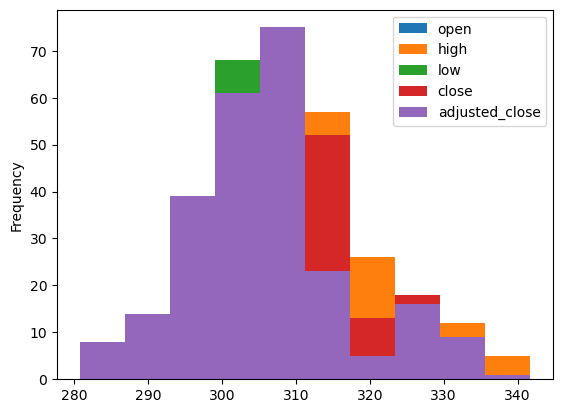

In [28]:
df[['open', 'high', 'low', 'close', 'adjusted_close']].plot(kind='hist')

In [29]:
df

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
2025-04-28,2025-04-28,317.70,318.02,314.25,316.81,309.6590,2578300
...,...,...,...,...,...,...,...
2026-04-15,2026-04-15,303.27,306.94,303.00,306.26,306.2600,2976500
2026-04-16,2026-04-16,306.58,308.27,304.57,306.96,306.9600,2334400
2026-04-17,2026-04-17,307.31,312.54,307.20,311.36,311.3600,3225500


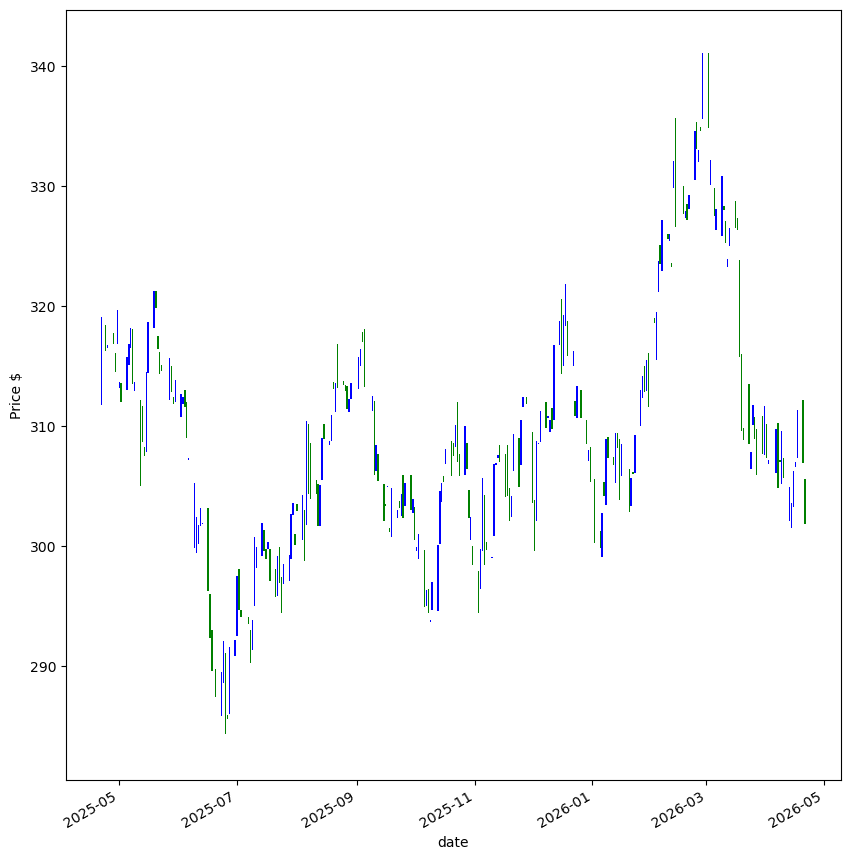

In [30]:
plt.figure(figsize=(10,10))
stock_prices=df
# "up" dataframe will store the stock_prices 
# when the closing stock price is greater
# than or equal to the opening stock prices
up = stock_prices[stock_prices.close >= stock_prices.open]

# "down" dataframe will store the stock_prices
# when the closing stock price is
# lesser than the opening stock prices
down = stock_prices[stock_prices.close < stock_prices.open]

# When the stock prices have decreased, then it
# will be represented by blue color candlestick
col1 = 'blue'

# When the stock prices have increased, then it 
# will be represented by green color candlestick
col2 = 'green'

# Setting width of candlestick elements
width = .7
width2 = .09

# Plotting up prices of the stock
plt.bar(up.index, up.close-up.open, width, bottom=up.open, color=col1)
plt.bar(up.index, up.high-up.close, width2, bottom=up.close, color=col1)
plt.bar(up.index, up.low-up.open, width2, bottom=up.open, color=col1)

# Plotting down prices of the stock
plt.bar(down.index, down.close-down.open, width, bottom=down.open, color=col2)
plt.bar(down.index, down.high-down.open, width2, bottom=down.open, color=col2)
plt.bar(down.index, down.low-down.close, width2, bottom=down.close, color=col2)

# rotating the x-axis tick labels at 30degree 
# towards right
plt.xticks(rotation=30, ha='right')

# displaying candlestick chart of stock data 
# of a week
plt.xlabel("date") 
plt.ylabel("Price $")
plt.show()

In [31]:
df.corr(numeric_only=True)

,open,high,low,close,adjusted_close,volume
open,1.000000,0.982980,0.982822,0.963031,0.950789,-0.176210
high,0.982980,1.000000,0.986162,0.985424,0.970476,-0.124261
low,0.982822,0.986162,1.000000,0.983508,0.968087,-0.202803
close,0.963031,0.985424,0.983508,1.000000,0.981197,-0.140549
adjusted_close,0.950789,0.970476,0.968087,0.981197,1.000000,-0.141231
volume,-0.176210,-0.124261,-0.202803,-0.140549,-0.141231,1.000000


<Axes: xlabel='date'>

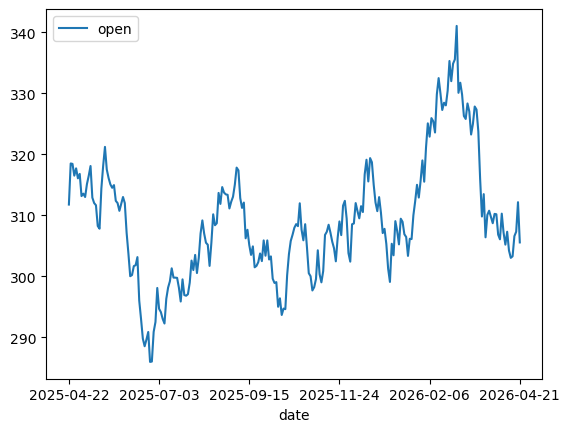

In [32]:
df.plot(kind='line', x='date', y='open')

<Axes: xlabel='date'>

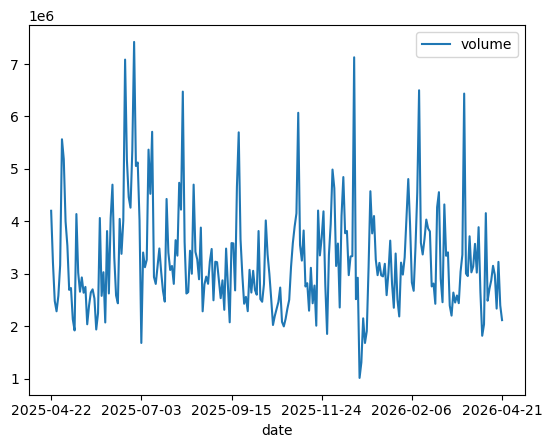

In [33]:
df.plot(kind='line', x='date', y='volume')

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [35]:
series = df['volume']
result = seasonal_decompose(series, model='additive', period=12)

In [36]:
result

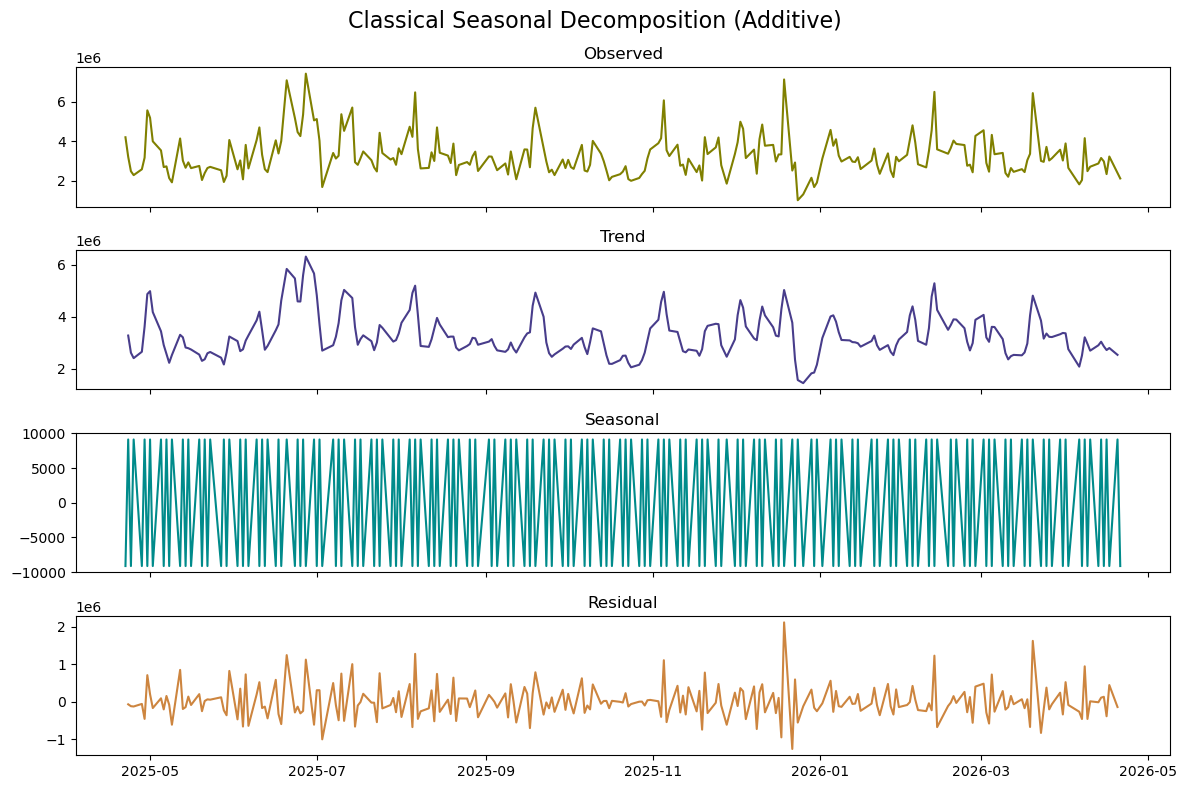

In [37]:
series = df['volume']
result = seasonal_decompose(series, model='additive', period=2)

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axs[0].plot(result.observed, color='olive')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='darkslateblue')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkcyan')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='peru')
axs[3].set_title('Residual')

plt.suptitle('Classical Seasonal Decomposition (Additive)', fontsize=16)
plt.tight_layout()
plt.show()

In [38]:
# using a statistical test for volume
from scipy.stats import kruskal

# Detecting anomalies

since i only have a year's worth of data, I will need to use more simple methods

In [39]:
open = df['open']

In [40]:
# method 1 - using standard deviation

rolling_deviations = pd.Series(dtype=float, index=open.index)
for date in rolling_deviations.index:
    window = open.loc[:date]
    rolling_deviations.loc[date]=window.std() 

    

In [41]:
rolling_deviations

date
2025-04-22          NaN
2025-04-23     4.765900
2025-04-24     3.871292
2025-04-25     3.163778
2025-04-28     2.810786
                ...    
2026-04-15    10.000731
2026-04-16     9.981823
2026-04-17     9.962370
2026-04-20     9.944150
2026-04-21     9.926866
Length: 251, dtype: float64

In [42]:
diff_rolling_deviations = rolling_deviations.diff() 
diff_rolling_deviations=diff_rolling_deviations.dropna()

In [43]:
diff_rolling_deviations

date
2025-04-24   -0.894608
2025-04-25   -0.707514
2025-04-28   -0.352992
2025-04-29   -0.287864
2025-04-30   -0.217061
                ...   
2026-04-15   -0.013263
2026-04-16   -0.018908
2026-04-17   -0.019454
2026-04-20   -0.018220
2026-04-21   -0.017283
Length: 249, dtype: float64

In [44]:
diff_rolling_deviations_df = pd.DataFrame(diff_rolling_deviations, columns=['deviation'])
diff_rolling_deviations_df

,deviation
date,
2025-04-24,-0.894608
2025-04-25,-0.707514
2025-04-28,-0.352992
2025-04-29,-0.287864
2025-04-30,-0.217061
...,...
2026-04-15,-0.013263
2026-04-16,-0.018908
2026-04-17,-0.019454


In [45]:
# deviation differences

start_date = open.index.min()
end_date=open.index.max() 

start_date

Timestamp('2025-04-22 00:00:00')

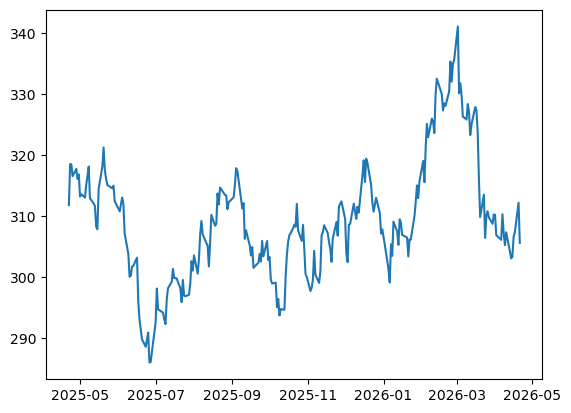

In [49]:
plt.plot(df.index, df.open)

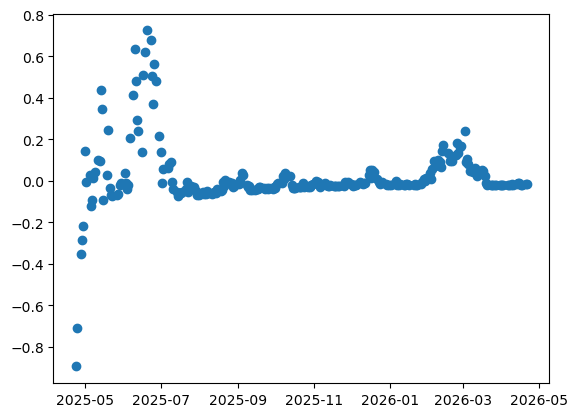

In [50]:
plt.scatter(x=diff_rolling_deviations_df.index, y=diff_rolling_deviations_df.deviation)

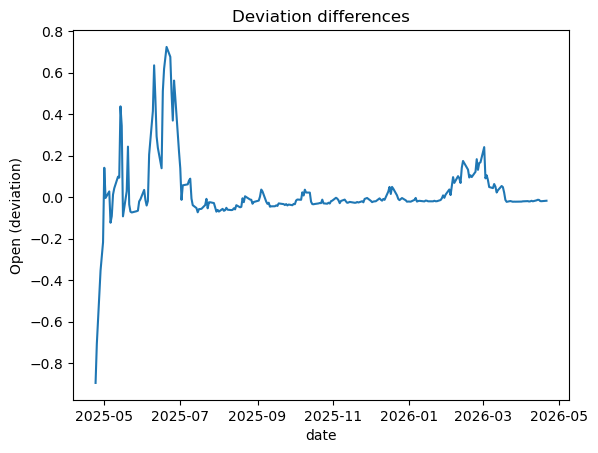

In [51]:
# deviation by month
plt.plot(diff_rolling_deviations)
plt.title("Deviation differences") 
plt.ylabel("Open (deviation)") 
plt.xlabel("date")
plt.show()

In [52]:
open

date
2025-04-22    311.76
2025-04-23    318.50
2025-04-24    318.43
2025-04-25    316.50
2025-04-28    317.70
               ...  
2026-04-15    303.27
2026-04-16    306.58
2026-04-17    307.31
2026-04-20    312.15
2026-04-21    305.55
Name: open, Length: 251, dtype: float64

In [53]:
start_date.month

4

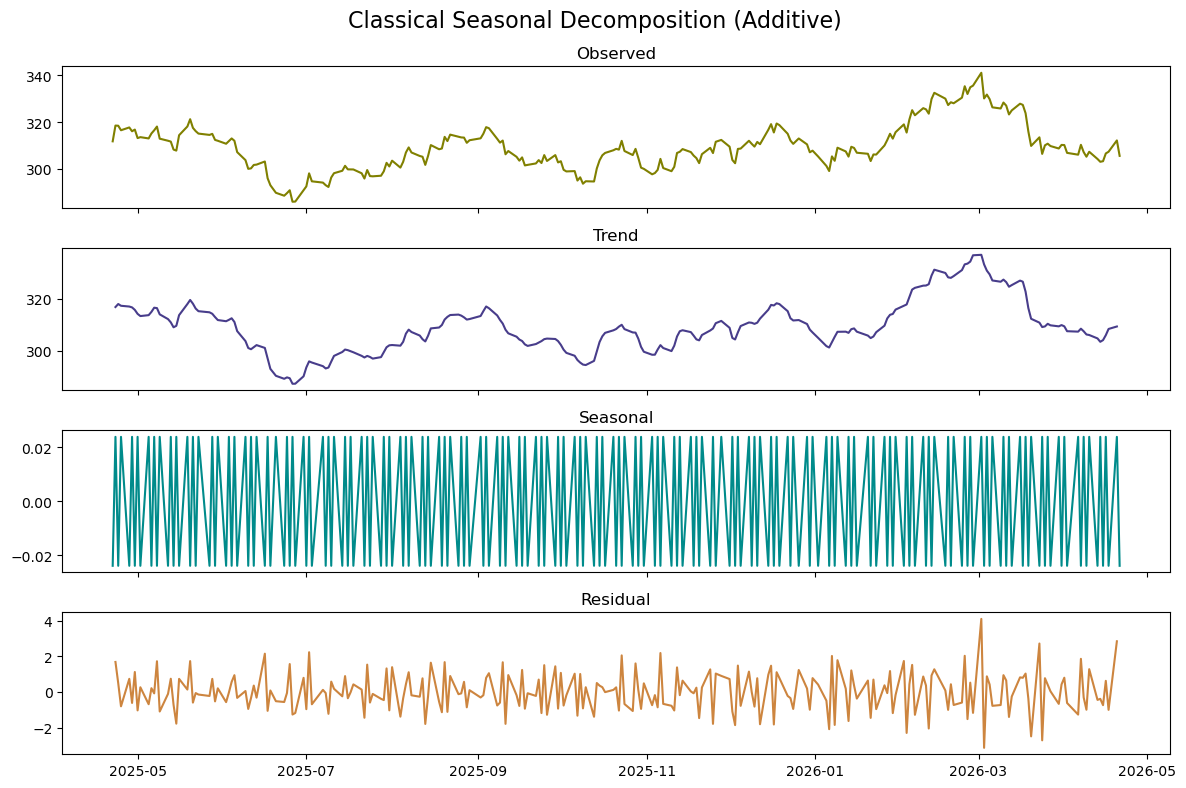

In [54]:
series = df['open']
result = seasonal_decompose(series, model='additive', period=2)

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axs[0].plot(result.observed, color='olive')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='darkslateblue')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkcyan')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='peru')
axs[3].set_title('Residual')

plt.suptitle('Classical Seasonal Decomposition (Additive)', fontsize=16)
plt.tight_layout()
plt.show()

In [55]:
# we know there is seasonality in "open", so we can use method 2

month_deviations=open.groupby(lambda d:d.week).std()

In [56]:
month_deviations

date
1     2.145342
2     3.829234
3     1.680783
4     1.452753
5     2.257636
6     3.674799
7     3.622986
8     1.150507
9     2.292396
10    5.546064
11    1.943412
12    7.829123
13    2.533097
14    1.599945
15    1.921986
16    1.954623
17    5.015220
18    2.008121
19    2.237963
20    2.760621
21    2.343175
22    1.487982
23    2.268552
24    1.500560
25    5.706735
26    2.182469
27    3.113170
28    2.427350
29    0.793839
30    1.398707
31    2.632461
32    3.489817
33    3.008667
34    2.840162
35    1.086200
36    2.214746
37    2.900936
38    1.723781
39    1.425956
40    2.852371
41    2.079418
42    4.950114
43    1.769090
44    3.637846
45    2.602378
46    4.246707
47    1.815605
48    2.558567
49    3.230306
50    0.961161
51    1.677519
52    1.808167
Name: open, dtype: float64

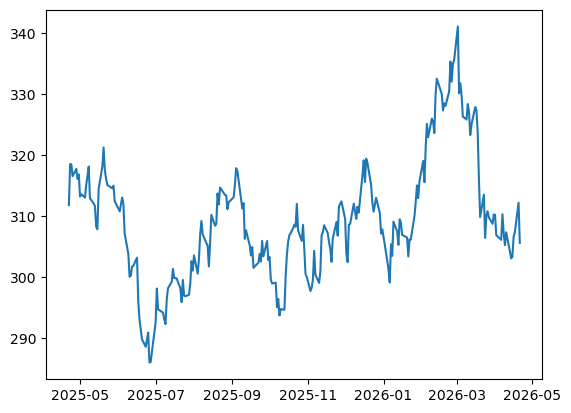

In [57]:
plt.plot(df.index, df.open)

Text(0, 0.5, '$')

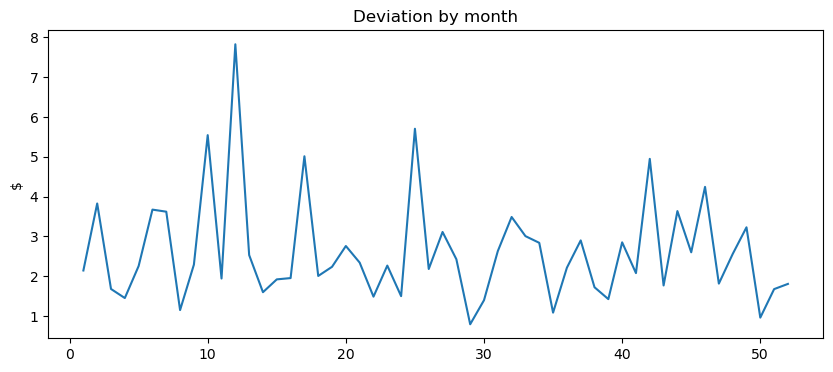

In [58]:
plt.figure(figsize=(10,4)) 
plt.plot(month_deviations)
plt.title("Deviation by month") 
plt.ylabel("$")

In [59]:
min_dev=2
curr_anomaly = None 
for date in month_deviations.index: 
    other_date = month_deviations[month_deviations.index != date]
    curr_dev = other_date.std() 
    if curr_dev < min_dev:
        min_dev = curr_dev 
        curr_anomaly=date 

In [60]:
curr_anomaly
# anomaly is at 13th apritl 2026

12

In [61]:
from statsmodels.tsa.seasonal import STL

<Axes: xlabel='date'>

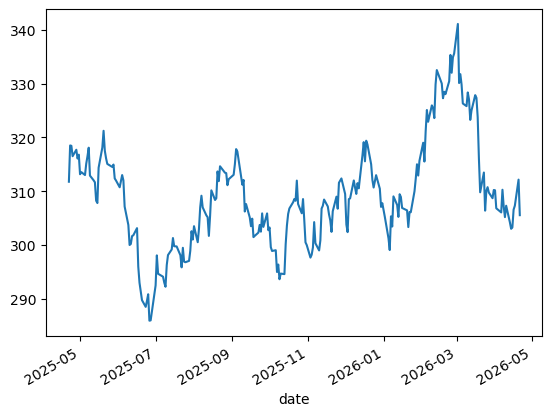

In [62]:
df['open'].plot(kind='line')

In [63]:
df

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
2025-04-28,2025-04-28,317.70,318.02,314.25,316.81,309.6590,2578300
...,...,...,...,...,...,...,...
2026-04-15,2026-04-15,303.27,306.94,303.00,306.26,306.2600,2976500
2026-04-16,2026-04-16,306.58,308.27,304.57,306.96,306.9600,2334400
2026-04-17,2026-04-17,307.31,312.54,307.20,311.36,311.3600,3225500


In [64]:
open_price = pd.DataFrame(df[['open', 'volume', 'high', 'low', 'adjusted_close']])


stl = STL(open_price['open'], period=2) 
result = stl.fit()

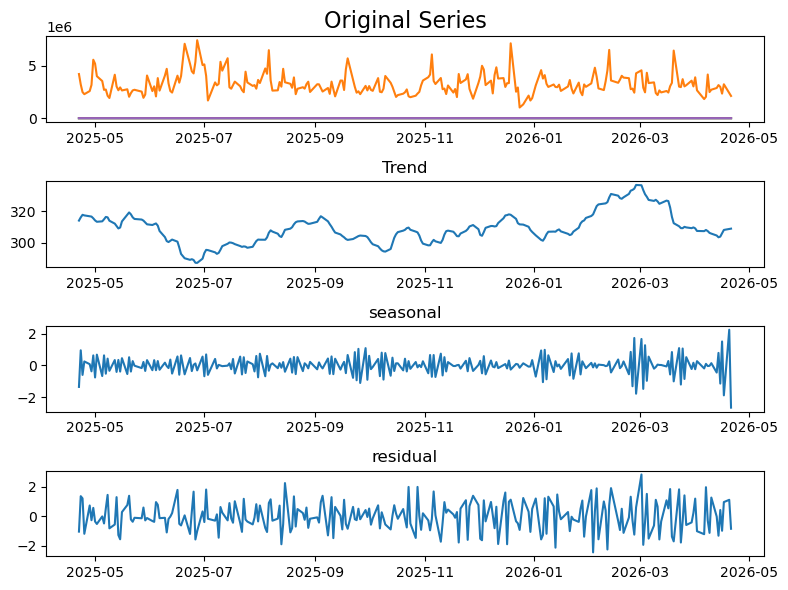

In [65]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid 

plt.figure(figsize=(8,6)) 
plt.subplot(4,1,1) 
plt.plot(open_price) 
plt.title("Original Series", fontsize=16) 

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend") 

plt.subplot(4,1,3) 
plt.plot(seasonal) 
plt.title("seasonal") 

plt.subplot(4,1,4) 
plt.plot(resid) 
plt.title("residual")
plt.tight_layout()

In [66]:
open_price.head()

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906
2025-04-28,317.70,2578300,318.02,314.25,309.6590


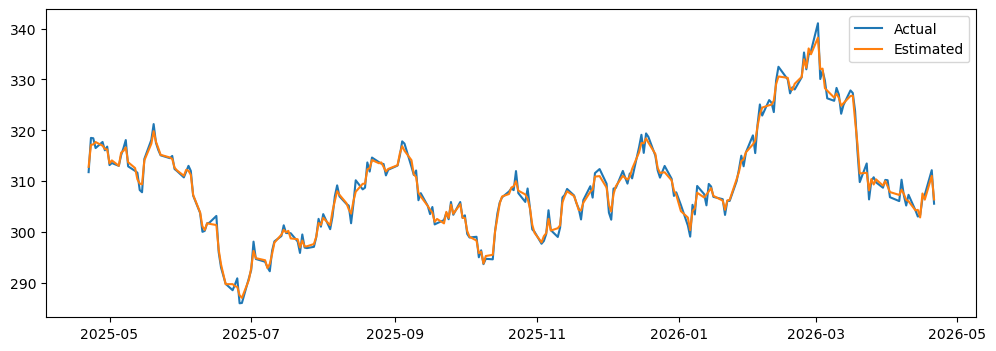

In [67]:
estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price.index, open_price.open) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

# anomaly detection

In [68]:
resid_mu = resid.mean() 
resid_dev = resid.std() 

lower=resid_mu - 3 * resid_dev 
upper = resid_mu + 3 * resid_dev 

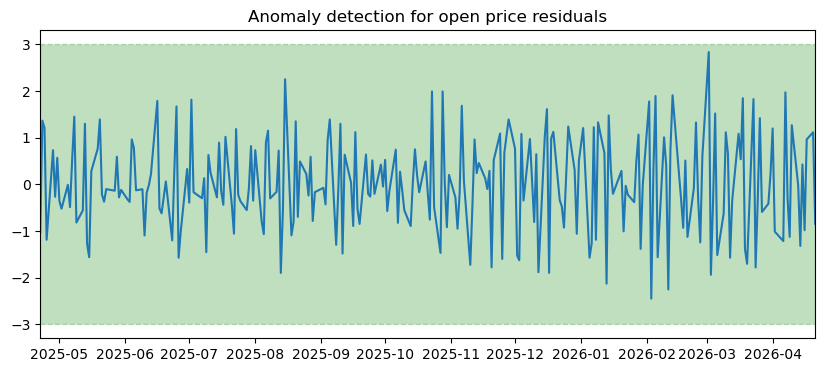

In [69]:
# checking if datapoints fit within 3 * std of mean

plt.figure(figsize=(10,4)) 
plt.plot(resid) 
plt.fill_between([min(open_price.index), max(open_price.index)], lower, upper, color='g', alpha=0.25, linestyle='--')
plt.xlim(min(open_price.index), max(open_price.index))
plt.title("Anomaly detection for open price residuals")
plt.show()

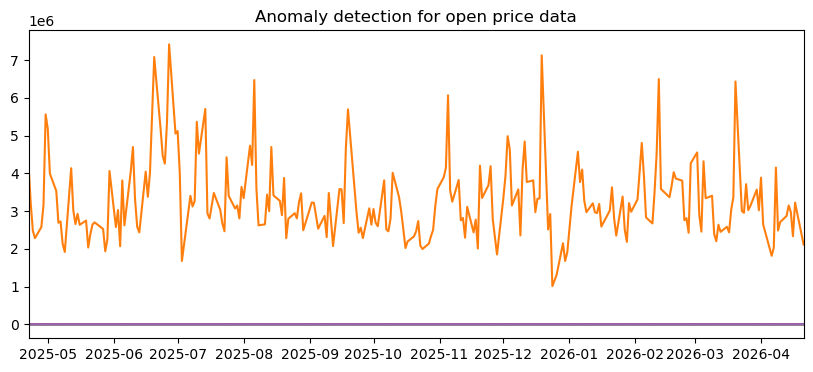

In [70]:
# checking if datapoints fit within 3 * std of mean
open_mu = open_price['open'].mean() 
open_dev = open_price['open'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(open_price) 
plt.fill_between([min(open_price.index), max(open_price.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(open_price.index), max(open_price.index))
plt.title("Anomaly detection for open price data")
plt.show()

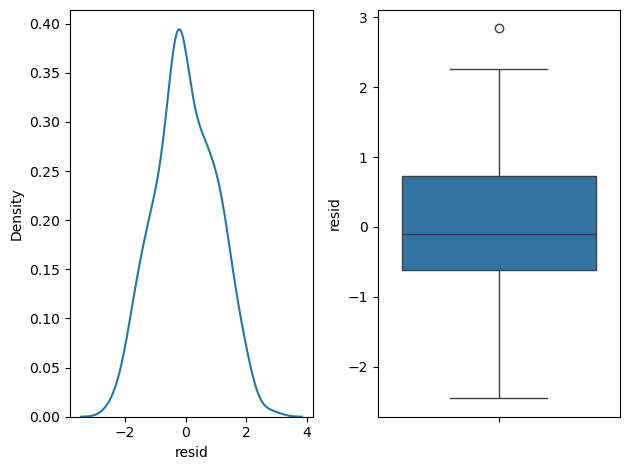

In [71]:
# testing the assumptions of this technique

# 1. normal distribution of data
# 2. sensitive to extreme outliers (boxplot?)


fig, axes = plt.subplots(1,2) 

# normal distribution 
sns.kdeplot(x=resid, ax=axes[0])

# extreme outliers
sns.boxplot(data=resid, ax=axes[1])



plt.tight_layout()
plt.show()

# Calculating VWAP

In [72]:
df.head()

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
2025-04-28,2025-04-28,317.70,318.02,314.25,316.81,309.6590,2578300


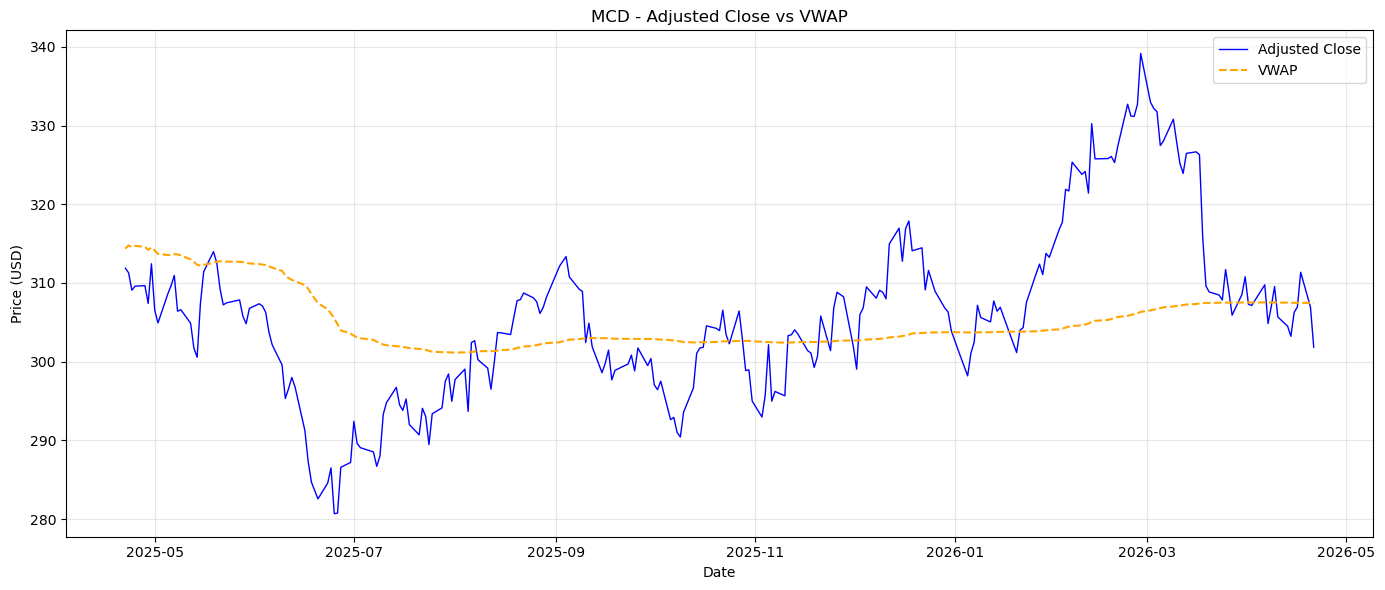

In [73]:
# VWAP

df['date'] = pd.to_datetime(df['date'])
df = df.sort_index(ascending=True)

# Calculate VWAP
# VWAP = cumulative(price * volume) / cumulative(volume)
df['typical_price'] = (df['high'] + df['low'] + df['adjusted_close']) / 3
df['tp_x_vol'] = df['typical_price'] * df['volume']
df['vwap'] = df['tp_x_vol'].cumsum() / df['volume'].cumsum()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['adjusted_close'], label='Adjusted Close', color='blue', linewidth=1)
plt.plot(df['date'], df['vwap'], label='VWAP', color='orange', linewidth=1.5, linestyle='--')

plt.title("MCD - Adjusted Close vs VWAP")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("vwap_plot.png")
plt.show()

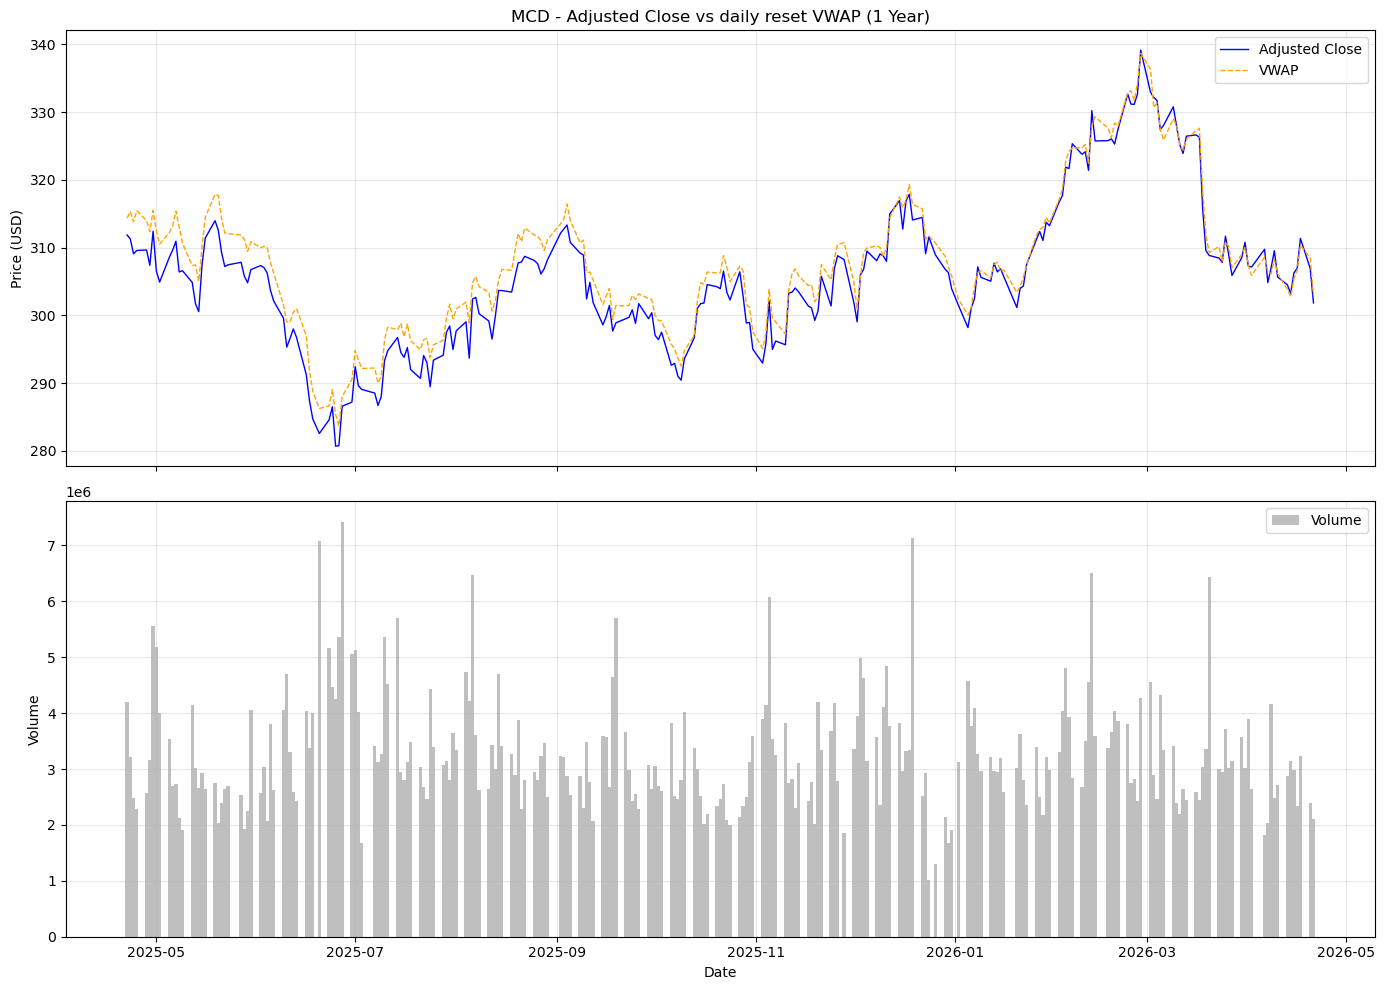

In [75]:
df['date'] = pd.to_datetime(df['date'])
df.sort_index(ascending=True, inplace=True)

# Calculate typical price
df['typical_price'] = (df['high'] + df['low'] + df['adjusted_close']) / 3
df['tp_x_vol'] = df['typical_price'] * df['volume']

# Reset VWAP each day
df['vwap'] = df.groupby(df['date'].dt.date).apply(
    lambda g: g['tp_x_vol'].cumsum() / g['volume'].cumsum()
).reset_index(level=0, drop=True)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price + VWAP
ax1.plot(df['date'], df['adjusted_close'], label='Adjusted Close', color='blue', linewidth=1)
ax1.plot(df['date'], df['vwap'], label='VWAP', color='orange', linewidth=1, linestyle='--')
ax1.set_title("MCD - Adjusted Close vs daily reset VWAP (1 Year)")
ax1.set_ylabel("Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volume bars
ax2.bar(df['date'], df['volume'], label='Volume', color='grey', alpha=0.5, width=1)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vwap_plot.png")
plt.show()

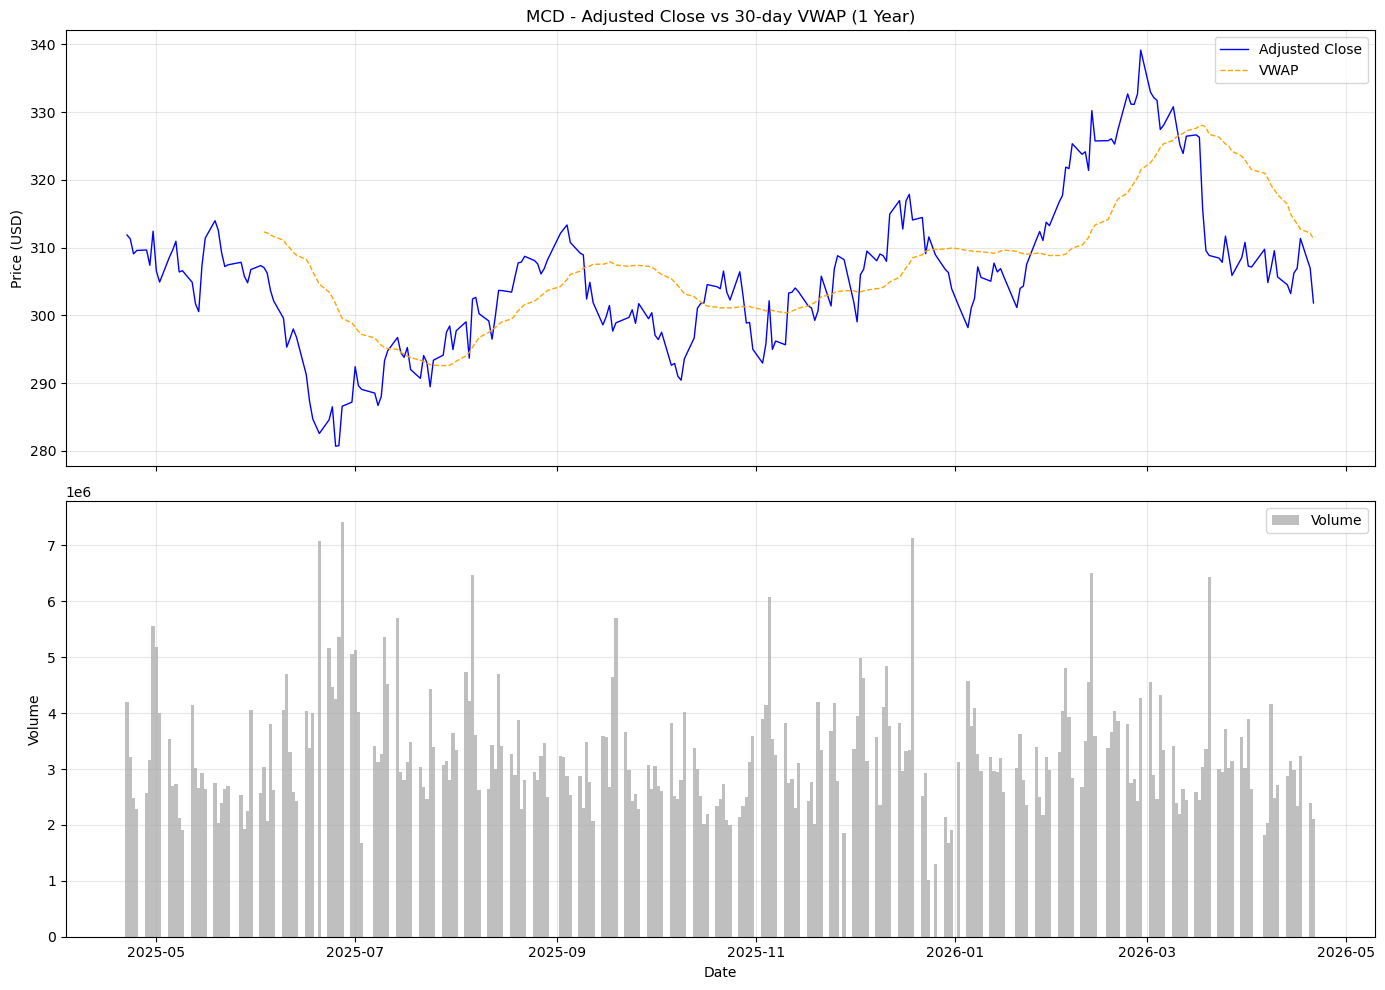

In [76]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_index(ascending=True)

# Calculate typical price
df['typical_price'] = (df['high'] + df['low'] + df['adjusted_close']) / 3
df['tp_x_vol'] = df['typical_price'] * df['volume']

# Reset VWAP every 20 days
window = 30
df['vwap'] = (
    df['tp_x_vol'].rolling(window).sum() / df['volume'].rolling(window).sum()
)
# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price + VWAP
ax1.plot(df['date'], df['adjusted_close'], label='Adjusted Close', color='blue', linewidth=1)
ax1.plot(df['date'], df['vwap'], label='VWAP', color='orange', linewidth=1, linestyle='--')
ax1.set_title("MCD - Adjusted Close vs 30-day VWAP (1 Year)")
ax1.set_ylabel("Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volume bars
ax2.bar(df['date'], df['volume'], label='Volume', color='grey', alpha=0.5, width=1)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vwap_plot.png")
plt.show()

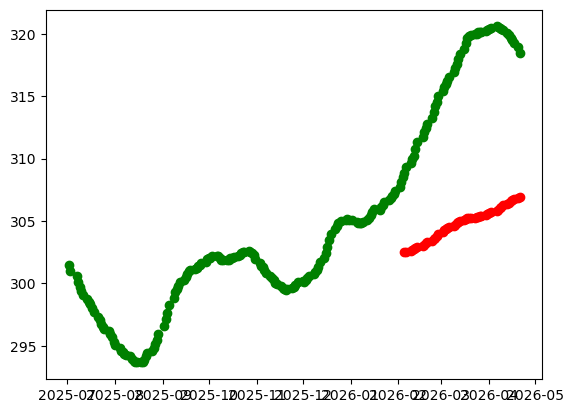

In [77]:
df['ma50'] = df['adjusted_close'].rolling(50).mean()
df['ma200'] = df['adjusted_close'].rolling(200).mean()

fig, ax1=plt.subplots()

ax1.scatter(df['date'], df['ma50'], label='50-day MA', color='green', linewidth=1)
ax1.scatter(df['date'], df['ma200'], label='200-day MA', color='red', linewidth=1)

plt.show()

In [78]:
ma_200_na = df['ma200'].dropna().values 
len(ma_200_na)

52

# testing for assumptions

In [79]:
# statistical test for normality

# null hypothesis is that the data is normally distributed
import scipy.stats as stats 

stats.shapiro(resid)

# the residuals are normally distributed

ShapiroResult(statistic=0.9926183665151477, pvalue=0.24601826053339043)

In [80]:
open_price

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906
2025-04-28,317.70,2578300,318.02,314.25,309.6590
...,...,...,...,...,...
2026-04-15,303.27,2976500,306.94,303.00,306.2600
2026-04-16,306.58,2334400,308.27,304.57,306.9600
2026-04-17,307.31,3225500,312.54,307.20,311.3600


# creating a model

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
open_price

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906
2025-04-28,317.70,2578300,318.02,314.25,309.6590
...,...,...,...,...,...
2026-04-15,303.27,2976500,306.94,303.00,306.2600
2026-04-16,306.58,2334400,308.27,304.57,306.9600
2026-04-17,307.31,3225500,312.54,307.20,311.3600


In [83]:
open_price

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906
2025-04-28,317.70,2578300,318.02,314.25,309.6590
...,...,...,...,...,...
2026-04-15,303.27,2976500,306.94,303.00,306.2600
2026-04-16,306.58,2334400,308.27,304.57,306.9600
2026-04-17,307.31,3225500,312.54,307.20,311.3600


In [84]:
open_price.index = pd.to_datetime(df['date'])
open_price.date = pd.to_datetime(df['date'])


/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_10698/3324650433.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  open_price.date = pd.to_datetime(df['date'])


In [85]:
open_price.head()

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906
2025-04-28,317.70,2578300,318.02,314.25,309.6590


In [86]:
lagged_volume = open_price['volume'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

open_price['lagged_volume'] = lagged_volume 

# lagged adjusted close
lagged_adjusted_close = open_price['adjusted_close'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
open_price['lagged_adjusted_close'] = lagged_adjusted_close


# lagged adjusted high
lagged_high = open_price['high'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
open_price['lagged_high'] = lagged_high 

# lagged low 
lagged_low = open_price['low'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
open_price['lagged_low'] = lagged_low 

open_price.head()









,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
date,,,,,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778,0,0.0000,0.00,0.00
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53
2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03


In [87]:
# dropping the first row
open_price = open_price[open_price.index != pd.to_datetime('2025-04-22')]


In [88]:
open_price

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
date,,,,,,,,,
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53
2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03
2025-04-29,316.06,3164500,316.73,313.00,307.4012,2578300,309.6590,318.02,314.25
...,...,...,...,...,...,...,...,...,...
2026-04-15,303.27,2976500,306.94,303.00,306.2600,3150100,303.2200,303.58,301.53
2026-04-16,306.58,2334400,308.27,304.57,306.9600,2976500,306.2600,306.94,303.00
2026-04-17,307.31,3225500,312.54,307.20,311.3600,2334400,306.9600,308.27,304.57


In [89]:
# testing xgboost


from xgboost import XGBRegressor 

In [90]:
open_price.head()

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
date,,,,,,,,,
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53
2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03
2025-04-29,316.06,3164500,316.73,313.00,307.4012,2578300,309.6590,318.02,314.25


In [91]:
open_price['day'] = open_price.index.day 
open_price['month'] = open_price.index.month
open_price['year'] = open_price.index.year 
open_price = open_price.sort_index(ascending=True)
X = open_price[['day', 'month', 'year', 'lagged_volume', 'lagged_high', 'lagged_low']]

# deleting the first row



X_train = X.head(175) 
X_test = X.tail(75)



Y_train = open_price['open'].head(175).values.reshape(-1,1) 
Y_test = open_price.open.tail(75).values.reshape(-1,1)

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_10698/1744347311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  open_price['day'] = open_price.index.day
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_10698/1744347311.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  open_price['month'] = open_price.index.month
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_10698/1744347311.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [92]:
model2 = XGBRegressor() 
model2.fit(X_train, Y_train)
predictions2 = model2.predict(X_test) 
predictions2 = pd.DataFrame(predictions2) 
predictions2.index = X_test.index 
predictions2.columns = ['prediction']


In [93]:
Y_test_df = pd.DataFrame(Y_test) 
Y_test_df.index = X_test.index 

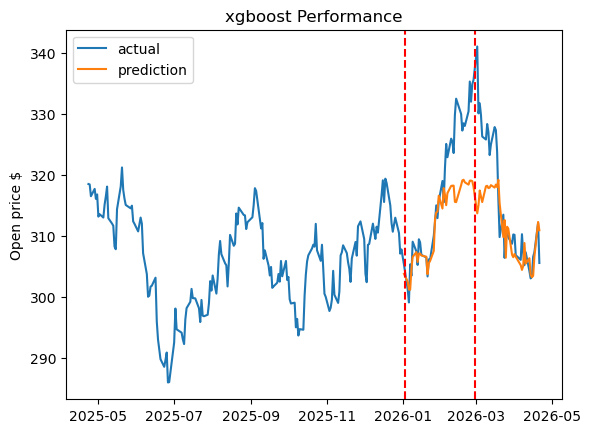

In [94]:
pred = model2.predict(X_test) 



plt.plot(open_price.index, open_price.open) 

plt.plot(X_test.index, pred) 


plt.axvline(x=pd.to_datetime('2026-02-28'), linestyle='--', color='r') 
plt.axvline(x=pd.to_datetime('2026-01-03'), linestyle='--', color='r')

plt.title("xgboost Performance")
plt.ylabel("Open price $")

plt.legend(['actual', 'prediction'])

Text(0, 0.5, ' pred')

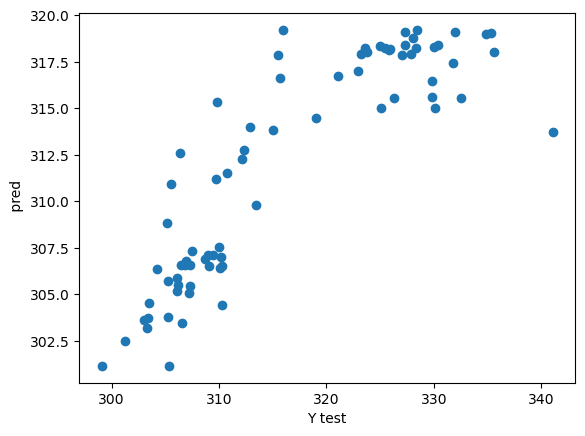

In [95]:
plt.scatter(Y_test, pred) 

plt.xlabel("Y test") 
plt.ylabel(" pred")

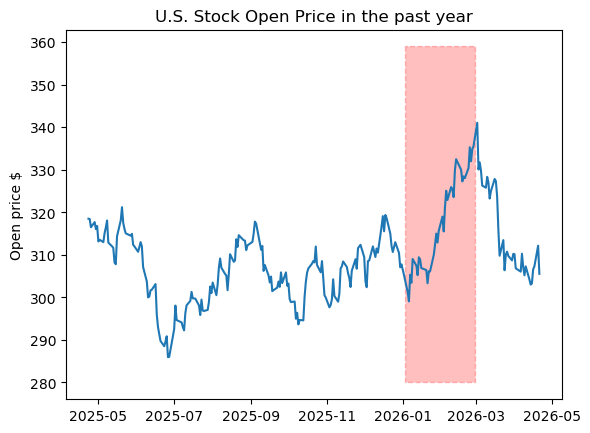

In [96]:
plt.plot(open_price.index, open_price.open) 





plt.fill_between(['2026-01-03', '2026-02-28'], 280, 359, linestyle='--', alpha=0.25, color='r')

plt.title("U.S. Stock Open Price in the past year")
plt.ylabel("Open price $")

plt.show()

In [97]:
# metrics

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [98]:
print (root_mean_squared_error(y_pred=predictions2, y_true=Y_test))
print (mean_absolute_error(y_pred=predictions2, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=predictions2))

7.846785048500618
5.613350520833331
0.4679390659294108


In [99]:
# optimising the model

from sklearn.model_selection import GridSearchCV

In [100]:
params = {
    'max_depth': [6, 10, 20, 30, 40, 50],
    'eta': [0.01, 0.1, 0.3],
    'tree_method': ['exact'],
    'min_child_weight': [0,1]

}


grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=params,
    verbose=3,
    scoring='r2',
    return_train_score=True
)

_ = grid_search.fit(X_train, Y_train) 

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.818, test=-0.182) total time=   0.2s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.811, test=-1.715) total time=   0.1s
[CV 3/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.824, test=0.593) total time=   0.1s
[CV 4/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.821, test=0.422) total time=   0.1s
[CV 5/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.824, test=0.455) total time=   0.1s
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=1, tree_method=exact;, score=(train=0.818, test=-0.182) total time=   0.1s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=1, tree_method=exact;, score=(train=0.811, test=-1.715) total time=   0.1s
[CV 3/5] END eta=0.01, max_depth=6, min_child

In [101]:
grid_search.best_params_

{'eta': 0.1, 'max_depth': 10, 'min_child_weight': 0, 'tree_method': 'exact'}

In [102]:
grid_search.best_score_

0.6161651895407443

In [103]:
X_test.head()

,day,month,year,lagged_volume,lagged_high,lagged_low
date,,,,,,
2026-01-02,2,1,2026,1903600,308.21,305.35
2026-01-05,5,1,2026,3124300,305.55,300.29
2026-01-06,6,1,2026,4573300,302.33,299.62
2026-01-07,7,1,2026,3769100,304.22,298.33
2026-01-08,8,1,2026,4100200,307.00,303.31


In [104]:
grid_predictions = grid_search.predict(X_test)
grid_predictions_df = pd.DataFrame(grid_predictions) 
grid_predictions_df.index = X_test.index 
grid_predictions_df.columns = ['prediction']

In [105]:
print (root_mean_squared_error(y_pred=grid_predictions, y_true=Y_test))
print (mean_absolute_error(y_pred=grid_predictions, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=grid_predictions))

7.668342342697743
5.601682210286456
0.49186296748150027


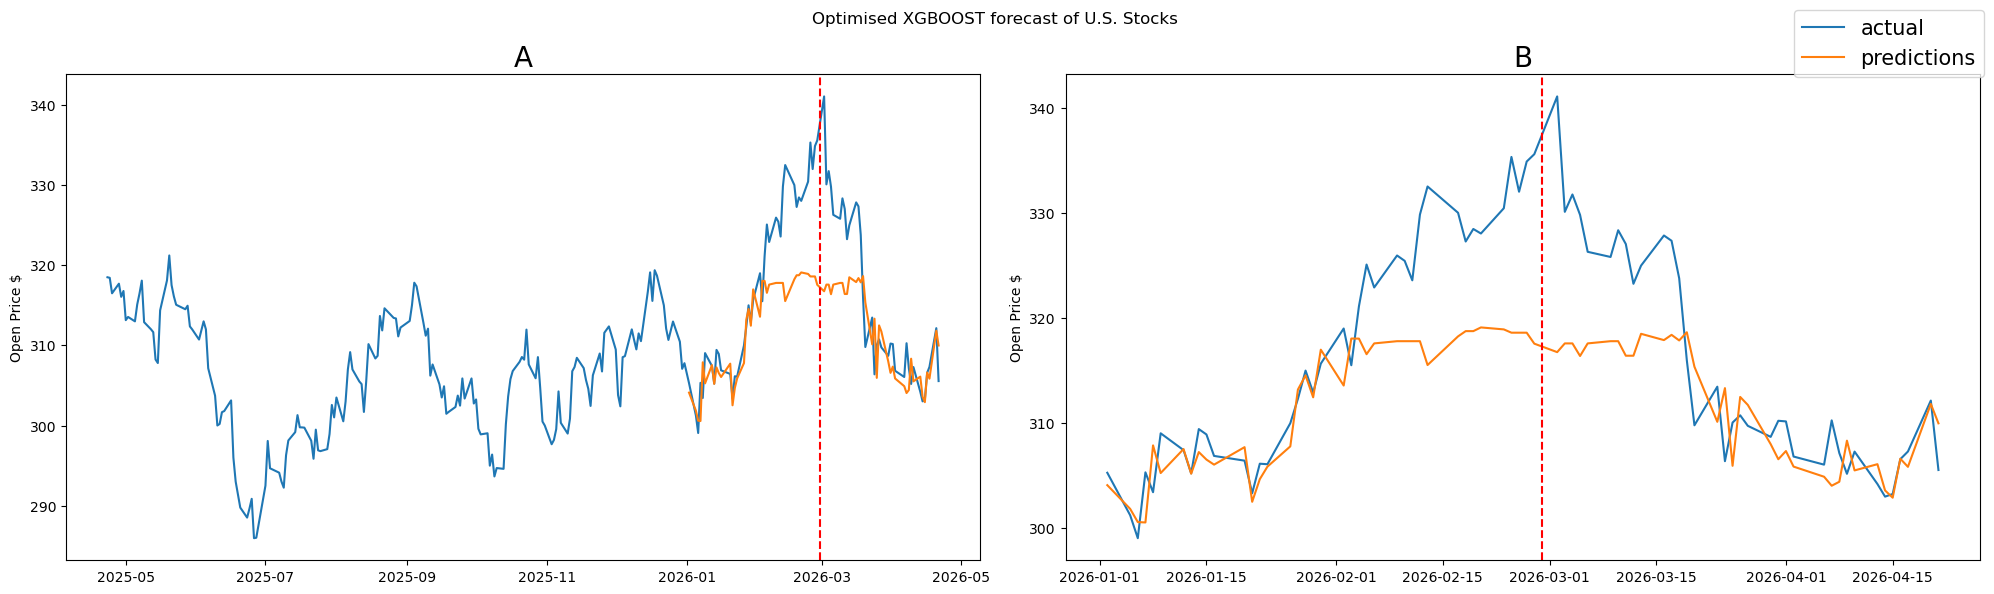

In [106]:

fig, axes=plt.subplots(1,2, figsize=(20,6)) 
fig.suptitle("Optimised XGBOOST forecast of U.S. Stocks")

axes[0].plot(open_price.index, open_price.open) 
axes[0].plot(X_test.index, grid_predictions) 
axes[0].axvline(pd.to_datetime('2026-02-28'), linestyle='--', color='r')
axes[0].set_title("A", fontsize=20)
axes[0].set_ylabel("Open Price $")

axes[1].plot(X_test.index, Y_test) 
axes[1].plot(X_test.index, grid_predictions) 
axes[1].axvline(pd.to_datetime('2026-02-28'), linestyle='--', color='r')
axes[1].set_title("B", fontsize=20)
axes[1].set_ylabel("Open Price $")

fig.legend(['actual', 'predictions'], fontsize=15)
plt.tight_layout()
plt.show()

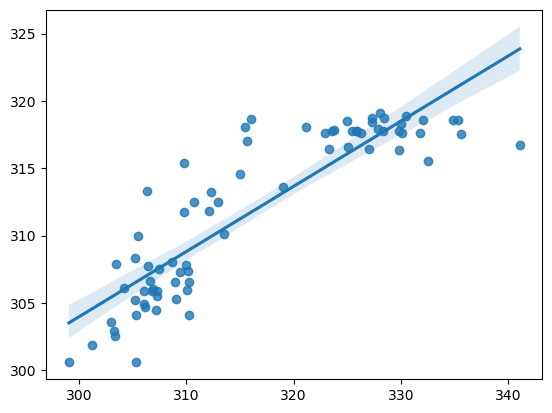

In [107]:
sns.regplot(x=Y_test, y=grid_predictions)

plt.show()

In [108]:
X

,day,month,year,lagged_volume,lagged_high,lagged_low
date,,,,,,
2025-04-23,23,4,2025,4200700,320.00,311.19
2025-04-24,24,4,2025,3210100,319.90,314.79
2025-04-25,25,4,2025,2479500,318.89,313.53
2025-04-28,28,4,2025,2282900,321.78,315.03
2025-04-29,29,4,2025,2578300,318.02,314.25
...,...,...,...,...,...,...
2026-04-15,15,4,2026,3150100,303.58,301.53
2026-04-16,16,4,2026,2976500,306.94,303.00
2026-04-17,17,4,2026,2334400,308.27,304.57


In [109]:
#€ using decision tree
from sklearn.tree import DecisionTreeRegressor

clf = DecisionTreeRegressor()

clf.fit(X_train, Y_train) 

pred = clf.predict(X_test) 

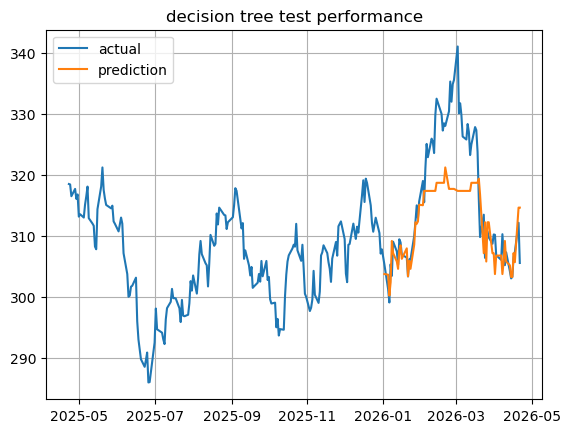

In [110]:
plt.plot(open_price.index, open_price.open) 

plt.plot(X_test.index, pred) 


plt.legend(['actual', 'prediction']) 

plt.title("decision tree test performance") 
plt.grid(True)
plt.show()

# incorporating news feed data

In [335]:
import sys 
sys.path.append("../scripts/")
sys.path.append("../models/sentiment_analyser")

import re

In [336]:
# incorporating news text

news = pd.read_csv("../financial_data/news/news_22_4_2026.csv")

In [337]:
news = news.sort_values(['date'], ascending=True)

In [338]:
news['date'] = pd.to_datetime(news['date'])
news

,topic,date,text
170,"armed conflicts and attacks,business and econo...",2025-01-01,"Gaza war,,Israeli invasion of the Gaza Strip,,..."
192,"armed conflicts and attacks,business and econo...",2025-01-02,"Syrian civil war,,Israeli invasion of Syria,,I..."
214,"armed conflicts and attacks,business and econo...",2025-01-03,"Syrian civil war,,East Aleppo offensive,,Clash..."
220,"armed conflicts and attacks,disasters and acci...",2025-01-04,"Russian invasion of Ukraine,,Eastern Ukraine c..."
222,"armed conflicts and attacks,arts and culture,d...",2025-01-05,"Russian invasion of Ukraine,,Kursk offensive,,..."
...,...,...,...
19,"armed conflicts and attacks,arts and culture,d...",2026-04-18,"Middle Eastern crisis,,Hezbollah–Israel confli..."
21,"armed conflicts and attacks,disasters and acci...",2026-04-19,"Middle Eastern crisis,,2026 Iran war,,2025–202..."
25,"armed conflicts and attacks,business and econo...",2026-04-20,"Middle Eastern crisis,,2026 Iran war,,2025–202..."
27,"armed conflicts and attacks,business and econo...",2026-04-21,"Middle Eastern crisis,,2026 Iran war,,2025–202..."


In [339]:
news[news.date == '2025-06-02']

,topic,date,text
274,"armed conflicts and attacks,business and econo...",2025-06-02,"Somali Civil War,,2025 Shabelle offensive,,Al-..."


In [340]:
np.unique(news.date.isna())

array([False])

In [341]:
news.isna().sum()

topic    0
date     0
text     0
dtype: int64

In [342]:

unique_topics = (
    news["topic"]
    .str.split(",")
    .explode()
    .str.strip().values
)
unique_topics

array(['armed conflicts and attacks', 'business and economics',
       'disasters and accidents', ..., 'business and economics',
       'law and crime and politics',
       'politics and elections and economics'], dtype=object)

In [343]:
len(np.unique(unique_topics))

10

In [344]:
np.unique(unique_topics)

array(['armed conflicts and attacks', 'arts and culture',
       'business and economics', 'disasters and accidents',
       'health and environment', 'international relations',
       'law and crime and politics',
       'politics and elections and economics', 'science and technology',
       'sports'], dtype=object)

In [345]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import spacy
stop_words = list(set(stopwords.words('english')))
nlp = spacy.load("en_core_web_sm")
def lemmatize(text):
    doc = nlp(text)
    # Turn it into tokens, ignoring the punctuation
    tokens = [token for token in doc if not token.is_punct]
    # Convert those tokens into lemmas, EXCEPT the pronouns, we'll keep those.
    lemmas = [token.lemma_ if token.pos_ != 'PRON' else token.orth_ for token in tokens]
    return lemmas



In [346]:
# performing some one hot encoding

sentiment_model = joblib.load("../models/sentiment_analyser/sentiment_analyser.pkl") 
sentiment_vectoriser = joblib.load("../models/sentiment_analyser/sentiment_vectoriser.pkl") 

def sentiment(text): 
    text_cleaned = re.sub("[^a-zA-Z]", " ", text)

    # analysing

    text_cleaned_tfidf = sentiment_vectoriser.transform([text_cleaned])

    prediction = sentiment_model.predict(text_cleaned_tfidf)
    return prediction[0]

news['sentiment'] = news['text'].apply(sentiment)

/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'ve", 'could', 'far', 'might', 'must', 'need', 'shall', 'win', 'would'] not in stop_words.
  warnings.warn(


In [347]:
news.info()

<class 'pandas.core.frame.DataFrame'>
Index: 477 entries, 170 to 29
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   topic      477 non-null    object        
 1   date       477 non-null    datetime64[ns]
 2   text       477 non-null    object        
 3   sentiment  477 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 18.6+ KB


In [348]:
news.isna().sum()

topic        0
date         0
text         0
sentiment    0
dtype: int64

In [349]:
news.head()

,topic,date,text,sentiment
170,"armed conflicts and attacks,business and econo...",2025-01-01,"Gaza war,,Israeli invasion of the Gaza Strip,,...",2
192,"armed conflicts and attacks,business and econo...",2025-01-02,"Syrian civil war,,Israeli invasion of Syria,,I...",2
214,"armed conflicts and attacks,business and econo...",2025-01-03,"Syrian civil war,,East Aleppo offensive,,Clash...",0
220,"armed conflicts and attacks,disasters and acci...",2025-01-04,"Russian invasion of Ukraine,,Eastern Ukraine c...",2
222,"armed conflicts and attacks,arts and culture,d...",2025-01-05,"Russian invasion of Ukraine,,Kursk offensive,,...",2


In [350]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-04-22 to 2026-04-21
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            251 non-null    datetime64[ns]
 1   open            251 non-null    float64       
 2   high            251 non-null    float64       
 3   low             251 non-null    float64       
 4   close           251 non-null    float64       
 5   adjusted_close  251 non-null    float64       
 6   volume          251 non-null    int64         
 7   typical_price   251 non-null    float64       
 8   tp_x_vol        251 non-null    float64       
 9   vwap            222 non-null    float64       
 10  ma50            202 non-null    float64       
 11  ma200           52 non-null     float64       
dtypes: datetime64[ns](1), float64(10), int64(1)
memory usage: 33.6 KB


In [351]:
news.date

170   2025-01-01
192   2025-01-02
214   2025-01-03
220   2025-01-04
222   2025-01-05
         ...    
19    2026-04-18
21    2026-04-19
25    2026-04-20
27    2026-04-21
29    2026-04-22
Name: date, Length: 477, dtype: datetime64[ns]

In [352]:
news

,topic,date,text,sentiment
170,"armed conflicts and attacks,business and econo...",2025-01-01,"Gaza war,,Israeli invasion of the Gaza Strip,,...",2
192,"armed conflicts and attacks,business and econo...",2025-01-02,"Syrian civil war,,Israeli invasion of Syria,,I...",2
214,"armed conflicts and attacks,business and econo...",2025-01-03,"Syrian civil war,,East Aleppo offensive,,Clash...",0
220,"armed conflicts and attacks,disasters and acci...",2025-01-04,"Russian invasion of Ukraine,,Eastern Ukraine c...",2
222,"armed conflicts and attacks,arts and culture,d...",2025-01-05,"Russian invasion of Ukraine,,Kursk offensive,,...",2
...,...,...,...,...
19,"armed conflicts and attacks,arts and culture,d...",2026-04-18,"Middle Eastern crisis,,Hezbollah–Israel confli...",2
21,"armed conflicts and attacks,disasters and acci...",2026-04-19,"Middle Eastern crisis,,2026 Iran war,,2025–202...",2
25,"armed conflicts and attacks,business and econo...",2026-04-20,"Middle Eastern crisis,,2026 Iran war,,2025–202...",2
27,"armed conflicts and attacks,business and econo...",2026-04-21,"Middle Eastern crisis,,2026 Iran war,,2025–202...",0


In [353]:
news.isna().sum()

topic        0
date         0
text         0
sentiment    0
dtype: int64

In [354]:
news[news.date == '2025-06-02']

,topic,date,text,sentiment
274,"armed conflicts and attacks,business and econo...",2025-06-02,"Somali Civil War,,2025 Shabelle offensive,,Al-...",2


In [355]:
open_price.reset_index(inplace=True)

In [362]:
open_price = pd.merge(open_price, news, how='left', on='date')

In [363]:
open_price.isna().sum()

level_0                  0
index                    0
date                     0
open                     0
volume                   0
high                     0
low                      0
adjusted_close           0
lagged_volume            0
lagged_adjusted_close    0
lagged_high              0
lagged_low               0
day                      0
month                    0
year                     0
topic                    0
text                     0
sentiment                0
dtype: int64

In [364]:
open_price.shape

(250, 18)

In [365]:
open_price[open_price.topic.isna()]

,level_0,index,date,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,topic,text,sentiment


In [366]:
open_price

,level_0,index,date,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,topic,text,sentiment
0,0,0,2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025,"armed conflicts and attacks,disasters and acci...","Russian invasion of Ukraine,,Attacks on civili...",1
1,1,1,2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025,"armed conflicts and attacks,arts and culture,d...","Israeli–Palestinian conflict,,Gaza war,,Israel...",2
2,2,2,2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025,"armed conflicts and attacks,arts and culture,b...","Kashmir conflict,,2025 India–Pakistan border s...",0
3,3,3,2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025,"armed conflicts and attacks,business and econo...","Kashmir conflict,,2025 India–Pakistan border s...",0
4,4,4,2025-04-29,316.06,3164500,316.73,313.00,307.4012,2578300,309.6590,318.02,314.25,29,4,2025,"armed conflicts and attacks,business and econo...","Kashmir conflict,,2025 India–Pakistan border s...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,245,245,2026-04-15,303.27,2976500,306.94,303.00,306.2600,3150100,303.2200,303.58,301.53,15,4,2026,"armed conflicts and attacks,business and econo...","Middle Eastern crisis,,2026 Iran war,,2025–202...",2
246,246,246,2026-04-16,306.58,2334400,308.27,304.57,306.9600,2976500,306.2600,306.94,303.00,16,4,2026,"armed conflicts and attacks,arts and culture,b...","Middle Eastern crisis,,2026 Iran war,,2025–202...",2
247,247,247,2026-04-17,307.31,3225500,312.54,307.20,311.3600,2334400,306.9600,308.27,304.57,17,4,2026,"armed conflicts and attacks,business and econo...","Middle Eastern crisis,,2026 Iran war,,2026 Str...",2
248,248,248,2026-04-20,312.15,2395200,312.53,305.95,306.9400,3225500,311.3600,312.54,307.20,20,4,2026,"armed conflicts and attacks,business and econo...","Middle Eastern crisis,,2026 Iran war,,2025–202...",2


In [367]:
open_price.drop(['topic', 'text'], axis=1, inplace=True)

In [368]:
open_price.index = pd.to_datetime(open_price['date']) 
open_price.drop(['date'], axis=1, inplace=True) 
open_price

,level_0,index,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
date,,,,,,,,,,,,,,,
2025-04-23,0,0,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025,1
2025-04-24,1,1,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025,2
2025-04-25,2,2,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025,0
2025-04-28,3,3,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025,0
2025-04-29,4,4,316.06,3164500,316.73,313.00,307.4012,2578300,309.6590,318.02,314.25,29,4,2025,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-15,245,245,303.27,2976500,306.94,303.00,306.2600,3150100,303.2200,303.58,301.53,15,4,2026,2
2026-04-16,246,246,306.58,2334400,308.27,304.57,306.9600,2976500,306.2600,306.94,303.00,16,4,2026,2
2026-04-17,247,247,307.31,3225500,312.54,307.20,311.3600,2334400,306.9600,308.27,304.57,17,4,2026,2


In [370]:
# reimplementing hte model



X = open_price.drop(['open', 'high', 'low', 'volume', 'adjusted_close'], axis=1).reset_index().drop(['date'],axis=1)
y = open_price.open.values.reshape(-1,1) 
X

,level_0,index,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
0,0,0,4200700,311.8778,320.00,311.19,23,4,2025,1
1,1,1,3210100,311.2913,319.90,314.79,24,4,2025,2
2,2,2,2479500,309.0823,318.89,313.53,25,4,2025,0
3,3,3,2282900,309.5906,321.78,315.03,28,4,2025,0
4,4,4,2578300,309.6590,318.02,314.25,29,4,2025,0
...,...,...,...,...,...,...,...,...,...,...
245,245,245,3150100,303.2200,303.58,301.53,15,4,2026,2
246,246,246,2976500,306.2600,306.94,303.00,16,4,2026,2
247,247,247,2334400,306.9600,308.27,304.57,17,4,2026,2
248,248,248,3225500,311.3600,312.54,307.20,20,4,2026,2


In [378]:
X.drop(['index'],axis=1, inplace=True)

In [379]:
X = X.drop(['level_0'], axis=1)

KeyError: "['level_0'] not found in axis"

In [380]:
X.isna().sum()

lagged_volume            0
lagged_adjusted_close    0
lagged_high              0
lagged_low               0
day                      0
month                    0
year                     0
sentiment                0
dtype: int64

In [381]:
X_train = X.head(175)
X_test = X.tail(75) 

Y_train = np.reshape(y[0:175], (-1,1))
Y_test = np.reshape(y[175:250], (-1,1))

In [382]:
np.shape(Y_test)

(75, 1)

In [383]:
X_test

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
175,1903600,303.9322,308.21,305.35,2,1,2026,2
176,3124300,301.5753,305.55,300.29,5,1,2026,0
177,4573300,298.1942,302.33,299.62,6,1,2026,2
178,3769100,301.0880,304.22,298.33,7,1,2026,2
179,4100200,302.4703,307.00,303.31,8,1,2026,2
...,...,...,...,...,...,...,...,...
245,3150100,303.2200,303.58,301.53,15,4,2026,2
246,2976500,306.2600,306.94,303.00,16,4,2026,2
247,2334400,306.9600,308.27,304.57,17,4,2026,2
248,3225500,311.3600,312.54,307.20,20,4,2026,2


In [384]:
X_train

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
0,4200700,311.8778,320.00,311.19,23,4,2025,1
1,3210100,311.2913,319.90,314.79,24,4,2025,2
2,2479500,309.0823,318.89,313.53,25,4,2025,0
3,2282900,309.5906,321.78,315.03,28,4,2025,0
4,2578300,309.6590,318.02,314.25,29,4,2025,0
...,...,...,...,...,...,...,...,...
170,2922800,309.1132,314.12,310.63,24,12,2025,1
171,1011500,311.5894,313.40,310.28,26,12,2025,2
172,1308900,308.9541,313.26,309.87,29,12,2025,2
173,2148300,306.8160,311.10,308.22,30,12,2025,2


In [385]:
clf = XGBRegressor() 

clf.fit(X_train, Y_train) 

pred = clf.predict(X_test) 

In [386]:
print (root_mean_squared_error(y_pred=pred, y_true=Y_test))
print (mean_absolute_error(y_pred=pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=pred))

7.741236461875782
5.765549886067705
0.4821565018438293


In [404]:
params = {
    'max_depth': [6, 10, 20, 30, 50, 100, 200, 300, 400],
    'eta': [0.01, 0.1, 0.3],
    'tree_method': ['exact'],
    'min_child_weight': [0]

}


grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=params,
    verbose=3,
    scoring='r2',
    return_train_score=True
)

_ = grid_search.fit(X_train, Y_train) 

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.823, test=-0.268) total time=   0.2s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.819, test=-1.962) total time=   0.1s
[CV 3/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.828, test=0.609) total time=   0.1s
[CV 4/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.826, test=0.355) total time=   0.1s
[CV 5/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.828, test=0.590) total time=   0.1s
[CV 1/5] END eta=0.01, max_depth=10, min_child_weight=0, tree_method=exact;, score=(train=0.823, test=-0.280) total time=   0.1s
[CV 2/5] END eta=0.01, max_depth=10, min_child_weight=0, tree_method=exact;, score=(train=0.819, test=-2.017) total time=   0.1s
[CV 3/5] END eta=0.01, max_depth=10, min_ch

In [405]:
plt.style.use("bmh")

In [406]:
grid_search.best_score_

0.6754280916577258

In [407]:
print (root_mean_squared_error(y_pred=grid_predictions, y_true=Y_test))
print (mean_absolute_error(y_pred=grid_predictions, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=grid_predictions))

7.668342342697743
5.601682210286456
0.49186296748150027


In [408]:
X_test.index

RangeIndex(start=175, stop=250, step=1)

In [409]:
df.index

DatetimeIndex(['2025-04-22', '2025-04-23', '2025-04-24', '2025-04-25',
               '2025-04-28', '2025-04-29', '2025-04-30', '2025-05-01',
               '2025-05-02', '2025-05-05',
               ...
               '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13',
               '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
               '2026-04-20', '2026-04-21'],
              dtype='datetime64[ns]', name='date', length=251, freq=None)

In [410]:
X_test

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
175,1903600,303.9322,308.21,305.35,2,1,2026,2
176,3124300,301.5753,305.55,300.29,5,1,2026,0
177,4573300,298.1942,302.33,299.62,6,1,2026,2
178,3769100,301.0880,304.22,298.33,7,1,2026,2
179,4100200,302.4703,307.00,303.31,8,1,2026,2
...,...,...,...,...,...,...,...,...
245,3150100,303.2200,303.58,301.53,15,4,2026,2
246,2976500,306.2600,306.94,303.00,16,4,2026,2
247,2334400,306.9600,308.27,304.57,17,4,2026,2
248,3225500,311.3600,312.54,307.20,20,4,2026,2


In [411]:
open_price

,level_0,index,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
date,,,,,,,,,,,,,,,
2025-04-23,0,0,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025,1
2025-04-24,1,1,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025,2
2025-04-25,2,2,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025,0
2025-04-28,3,3,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025,0
2025-04-29,4,4,316.06,3164500,316.73,313.00,307.4012,2578300,309.6590,318.02,314.25,29,4,2025,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-15,245,245,303.27,2976500,306.94,303.00,306.2600,3150100,303.2200,303.58,301.53,15,4,2026,2
2026-04-16,246,246,306.58,2334400,308.27,304.57,306.9600,2976500,306.2600,306.94,303.00,16,4,2026,2
2026-04-17,247,247,307.31,3225500,312.54,307.20,311.3600,2334400,306.9600,308.27,304.57,17,4,2026,2


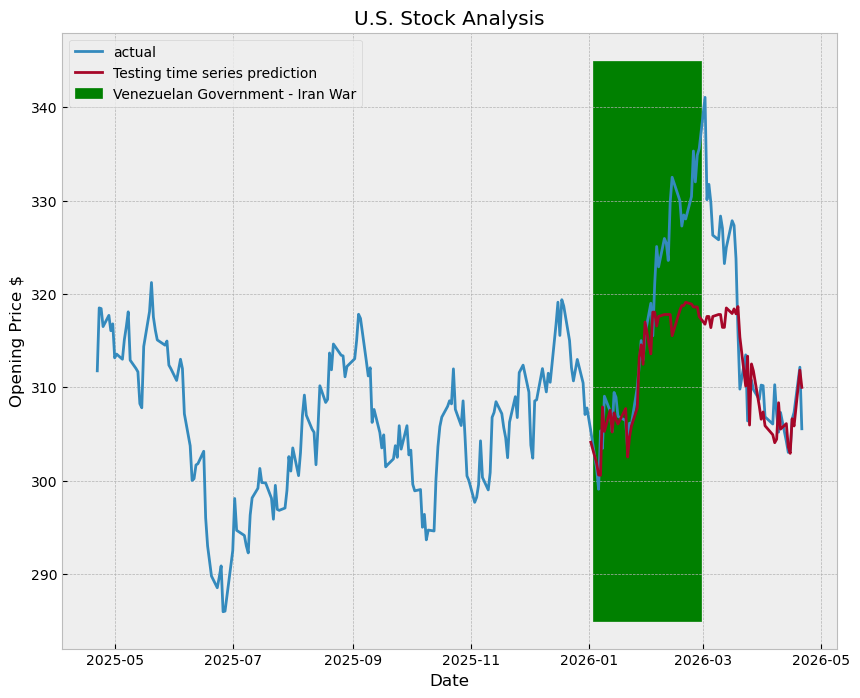

In [412]:
plt.figure(figsize=(10,8))

plt.plot(df.index, df.open)

plt.plot(pd.to_datetime(open_price.tail(75).index), grid_predictions)


plt.fill_between([pd.to_datetime('2026-01-03'), 
                  pd.to_datetime('2026-02-28')], 285, 345, color='g')

plt.legend(['actual', 'Testing time series prediction', "Venezuelan Government - Iran War"])
plt.xlabel("Date") 
plt.ylabel("Opening Price $")
plt.title("U.S. Stock Analysis")
plt.show()

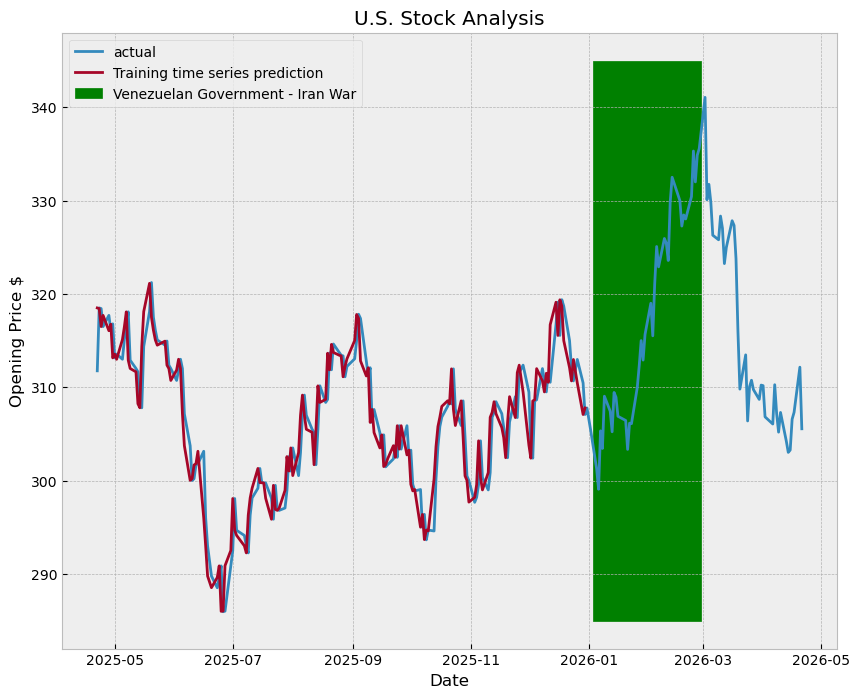

In [402]:
train_pred = grid_search.predict(X_train) 


plt.figure(figsize=(10,8))
plt.plot(df.index, df.open) 

plt.plot(df.head(175).index, train_pred)

plt.fill_between([pd.to_datetime('2026-01-03'), 
                  pd.to_datetime('2026-02-28')], 285, 345, color='g')

plt.legend(['actual', 'Training time series prediction', "Venezuelan Government - Iran War"])
plt.xlabel("Date") 
plt.ylabel("Opening Price $")
plt.title("U.S. Stock Analysis")
plt.show()

In [397]:
import shap

In [398]:
X_test

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
175,1903600,303.9322,308.21,305.35,2,1,2026,2
176,3124300,301.5753,305.55,300.29,5,1,2026,0
177,4573300,298.1942,302.33,299.62,6,1,2026,2
178,3769100,301.0880,304.22,298.33,7,1,2026,2
179,4100200,302.4703,307.00,303.31,8,1,2026,2
...,...,...,...,...,...,...,...,...
245,3150100,303.2200,303.58,301.53,15,4,2026,2
246,2976500,306.2600,306.94,303.00,16,4,2026,2
247,2334400,306.9600,308.27,304.57,17,4,2026,2
248,3225500,311.3600,312.54,307.20,20,4,2026,2


In [399]:
explainer = shap.TreeExplainer(grid_search.best_estimator_) 
shap_values = explainer(X_test)

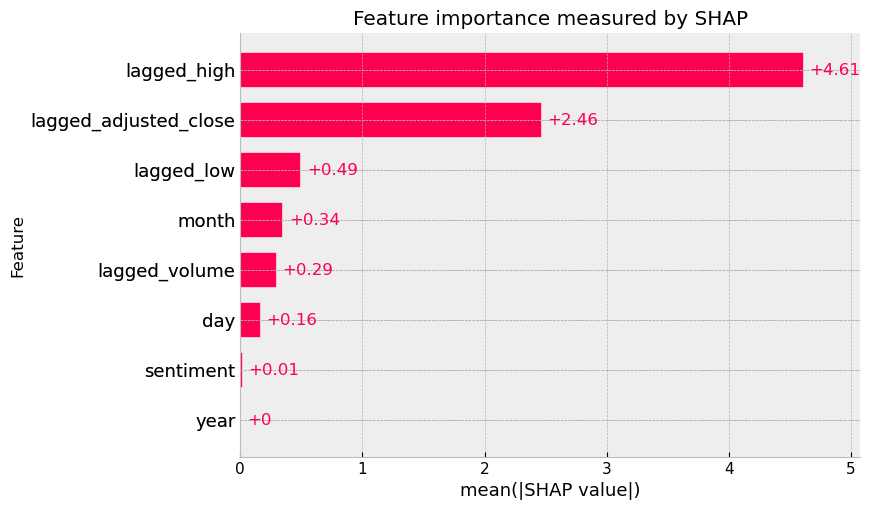

In [413]:
shap.plots.bar(shap_values, show=False) 

plt.title("Feature importance measured by SHAP")

plt.ylabel("Feature") 
plt.show()

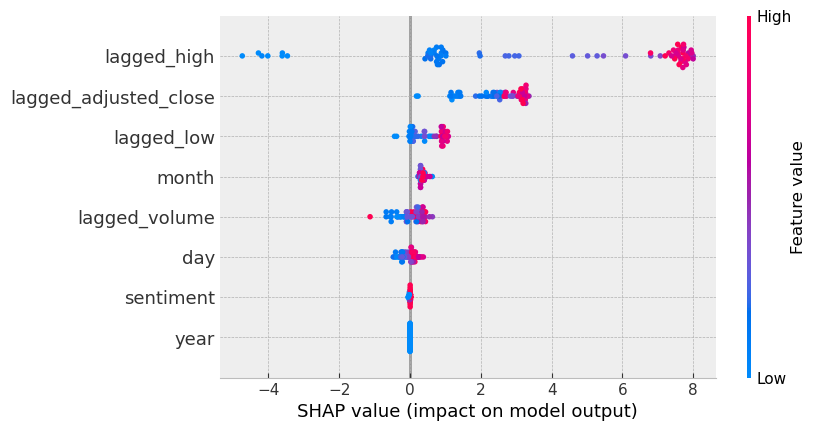

In [401]:
shap.plots.beeswarm(shap_values)